# Hello World Graph 

## **Objectives**

1. Understand and define the `AgentState` structure.
2. Create simple node functions to process and update state.
3. Set up a basic `LangGraph` structure.
4. Compile and invoke a LangGraph graph.
5. Understand how data flows through a single-node in `LangGraph`.

---

## Structure 

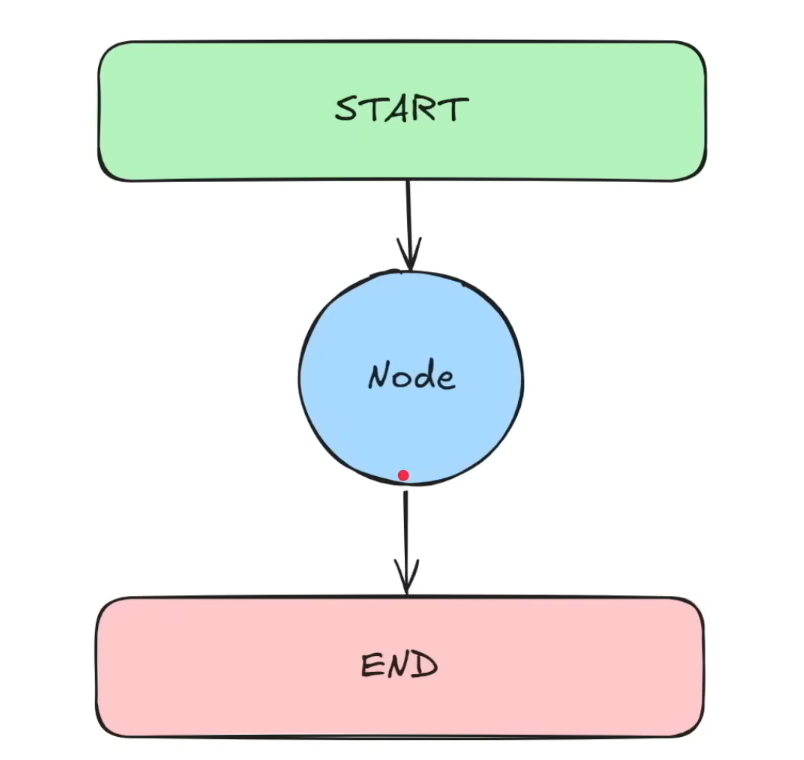

---

### 1. Importing libraries

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

### 2. Create the AgentState

It is a shared data structure that keeps track o information as our application runs

In [2]:
class AgentState(TypedDict): # Our state schema
    message : str 


### 3. Define the first node 

In [3]:
def greeting_node(state: AgentState) -> AgentState:
    # We need docstrings to tell the AI agent what the function actually does
    """
    Simple node that adds greeting message to the state
    """
    # We update the state of the message
    state['message'] = "Hey, " + state['message'] + ",how is your day going?"

    return state


### 4. Create the Graph

In [4]:
graph = StateGraph(AgentState)

# Add a node to the graph
# arguments: name of the node and what it will do
# In this case our node is greeter and perfoms the action of the greeting node function
graph.add_node("greeter", greeting_node)

### 5. Adding starting and ending point

In [5]:
# Takes argument of the starting node
graph.set_entry_point("greeter")

# Takes argument of the end node
graph.set_finish_point("greeter")

### 6. Compile the Graph

In [6]:
app = graph.compile()

### 7. We can yse IPtython to display the graph

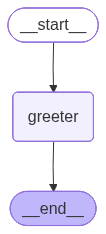

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### 8. Run the graph

In [8]:
result = app.invoke({"message": "Bob"})

result["message"]

'Hey, Bob,how is your day going?'

# Exercise for Graph 1 

Create a *personalized compliment agent* using LangGraph

Example:

```python
Input: {"name": "Bob"}

Output: "Bob, you´re doing an amazing job learning LangGraph"
```

In [9]:
class AgentState2(TypedDict):
    name : str


def compliment_node(state: AgentState2) -> AgentState2:
    """
    Node that compliments the person
    """

    state["name"] = state["name"] + ", " + "you´re doing an amazing job learning LangGraph"

    return state

graph_2 = StateGraph(AgentState2)

graph_2.add_node("complimenter", compliment_node)
# Takes argument of the starting node
graph_2.set_entry_point("complimenter")

# Takes argument of the end node
graph_2.set_finish_point("complimenter")

app = graph_2.compile()

result = app.invoke({"name": "Bob"})

result["name"]

'Bob, you´re doing an amazing job learning LangGraph'